<a href="https://colab.research.google.com/github/silvia-dev-prog/ai-agents-for-beginners/blob/main/RUSBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve)
from imblearn.ensemble import RUSBoostClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')

In [20]:
#Pré-processamento
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve)
from imblearn.ensemble import RUSBoostClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')

# Carregar os dados
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')  # ajuste o caminho se necessário
print("Dimensões:", df.shape)
print("\nPrimeiras linhas:")
display(df.head())
print("\nInformações:")
df.info()

Dimensões: (7043, 21)

Primeiras linhas:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Informações:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

Realizando validação cruzada...
F1-Score médio (Validação Cruzada): 0.5894 (+/- 0.0351)
Treinando o modelo no conjunto de treino completo...

Avaliação do Modelo no Conjunto de Teste:
              precision    recall  f1-score   support

           0       0.90      0.73      0.80      1035
           1       0.50      0.77      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.74      0.75      1409



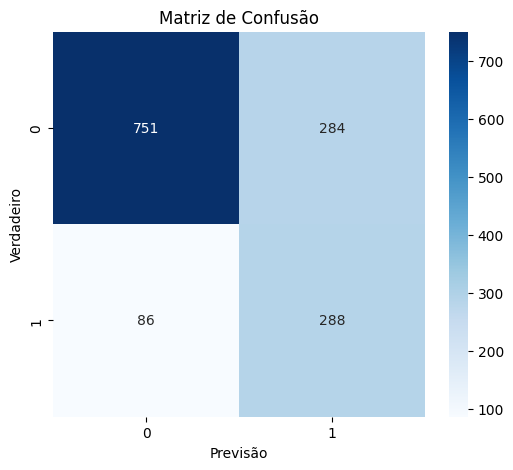

ROC AUC no Conjunto de Teste: 0.8111


In [27]:
# Treinar e avaliar o RUSBoostClassifier com validação cruzada

# Inicializar o modelo
rusboost = RUSBoostClassifier(random_state=42)

# Definir estratégia de validação cruzada estratificada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Realizar validação cruzada
print("Realizando validação cruzada...")
scores = cross_val_score(rusboost, X_train, y_train, cv=skf, scoring='f1', n_jobs=-1)

print(f"F1-Score médio (Validação Cruzada): {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")

# Treinar o modelo no conjunto de treino completo
print("Treinando o modelo no conjunto de treino completo...")
rusboost.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_pred = rusboost.predict(X_test)
y_proba = rusboost.predict_proba(X_test)[:, 1]

# Avaliar o desempenho no conjunto de teste
print("\nAvaliação do Modelo no Conjunto de Teste:")
print(classification_report(y_test, y_pred))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão')
plt.xlabel('Previsão')
plt.ylabel('Verdadeiro')
plt.show()

# ROC AUC
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC AUC no Conjunto de Teste: {roc_auc:.4f}")

Realizando validação cruzada...
F1-Score médio (Validação Cruzada): 0.5894 (+/- 0.0351)
Treinando o modelo no conjunto de treino completo...

Avaliação do Modelo no Conjunto de Teste:
              precision    recall  f1-score   support

           0       0.90      0.73      0.80      1035
           1       0.50      0.77      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.74      0.75      1409



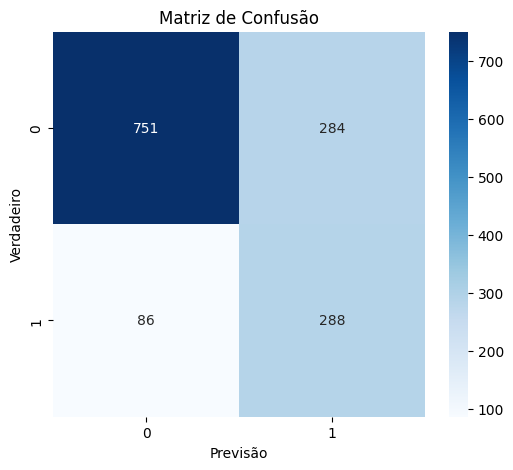

ROC AUC no Conjunto de Teste: 0.8111


In [28]:
# Treinar e avaliar o RUSBoostClassifier com validação cruzada

# Inicializar o modelo
rusboost = RUSBoostClassifier(random_state=42)

# Definir estratégia de validação cruzada estratificada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Realizar validação cruzada
print("Realizando validação cruzada...")
scores = cross_val_score(rusboost, X_train, y_train, cv=skf, scoring='f1', n_jobs=-1)

print(f"F1-Score médio (Validação Cruzada): {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")

# Treinar o modelo no conjunto de treino completo
print("Treinando o modelo no conjunto de treino completo...")
rusboost.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_pred = rusboost.predict(X_test)
y_proba = rusboost.predict_proba(X_test)[:, 1]

# Avaliar o desempenho no conjunto de teste
print("\nAvaliação do Modelo no Conjunto de Teste:")
print(classification_report(y_test, y_pred))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão')
plt.xlabel('Previsão')
plt.ylabel('Verdadeiro')
plt.show()

# ROC AUC
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC AUC no Conjunto de Teste: {roc_auc:.4f}")

Realizando validação cruzada...
F1-Score médio (Validação Cruzada): 0.5894 (+/- 0.0351)
Treinando o modelo no conjunto de treino completo...

Avaliação do Modelo no Conjunto de Teste:
              precision    recall  f1-score   support

           0       0.90      0.73      0.80      1035
           1       0.50      0.77      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.74      0.75      1409



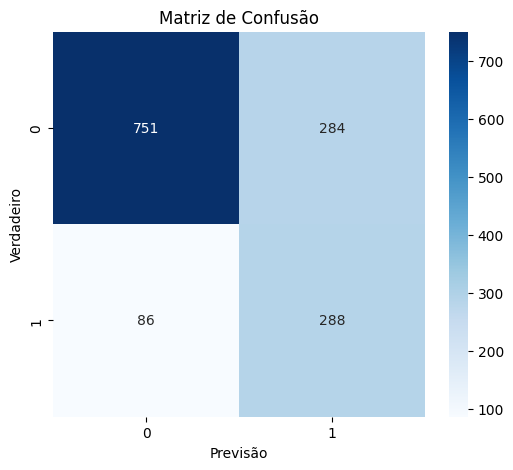

ROC AUC no Conjunto de Teste: 0.8111


In [29]:
# Treinar e avaliar o RUSBoostClassifier com validação cruzada

# Inicializar o modelo
rusboost = RUSBoostClassifier(random_state=42)

# Definir estratégia de validação cruzada estratificada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Realizar validação cruzada
print("Realizando validação cruzada...")
scores = cross_val_score(rusboost, X_train, y_train, cv=skf, scoring='f1', n_jobs=-1)

print(f"F1-Score médio (Validação Cruzada): {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")

# Treinar o modelo no conjunto de treino completo
print("Treinando o modelo no conjunto de treino completo...")
rusboost.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_pred = rusboost.predict(X_test)
y_proba = rusboost.predict_proba(X_test)[:, 1]

# Avaliar o desempenho no conjunto de teste
print("\nAvaliação do Modelo no Conjunto de Teste:")
print(classification_report(y_test, y_pred))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão')
plt.xlabel('Previsão')
plt.ylabel('Verdadeiro')
plt.show()

# ROC AUC
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC AUC no Conjunto de Teste: {roc_auc:.4f}")

Realizando validação cruzada...
F1-Score médio (Validação Cruzada): 0.5894 (+/- 0.0351)
Treinando o modelo no conjunto de treino completo...

Avaliação do Modelo no Conjunto de Teste:
              precision    recall  f1-score   support

           0       0.90      0.73      0.80      1035
           1       0.50      0.77      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.74      0.75      1409



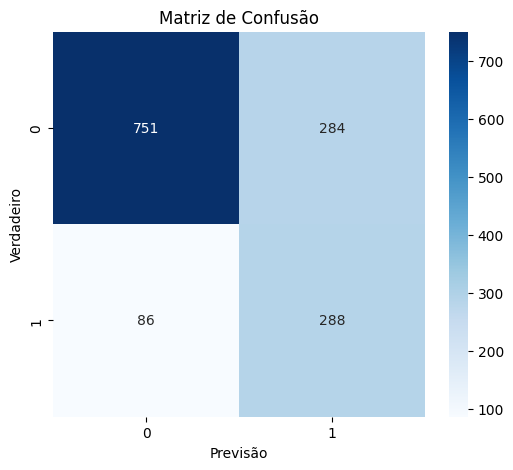

ROC AUC no Conjunto de Teste: 0.8111


In [30]:
# Treinar e avaliar o RUSBoostClassifier com validação cruzada

# Inicializar o modelo
rusboost = RUSBoostClassifier(random_state=42)

# Definir estratégia de validação cruzada estratificada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Realizar validação cruzada
print("Realizando validação cruzada...")
scores = cross_val_score(rusboost, X_train, y_train, cv=skf, scoring='f1', n_jobs=-1)

print(f"F1-Score médio (Validação Cruzada): {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")

# Treinar o modelo no conjunto de treino completo
print("Treinando o modelo no conjunto de treino completo...")
rusboost.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_pred = rusboost.predict(X_test)
y_proba = rusboost.predict_proba(X_test)[:, 1]

# Avaliar o desempenho no conjunto de teste
print("\nAvaliação do Modelo no Conjunto de Teste:")
print(classification_report(y_test, y_pred))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão')
plt.xlabel('Previsão')
plt.ylabel('Verdadeiro')
plt.show()

# ROC AUC
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC AUC no Conjunto de Teste: {roc_auc:.4f}")

In [21]:
df.drop('customerID', axis=1, inplace=True)

In [22]:
# Verificar tipo atual
print(df['TotalCharges'].dtype)  # provavelmente object

# Converter para numérico, forçando erros para NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Verificar quantos NaN foram introduzidos
print("Valores ausentes em TotalCharges:", df['TotalCharges'].isnull().sum())

object
Valores ausentes em TotalCharges: 11


In [23]:
#Preencher NaN com zero
df['TotalCharges'].fillna(0, inplace=True)

In [14]:
print("Valores ausentes em TotalCharges:", df['TotalCharges'].isnull().sum())

Valores ausentes em TotalCharges: 0


In [15]:
print("Valores ausentes em Churn:", df['Churn'].isnull().sum())

Valores ausentes em Churn: 7043


In [24]:
# Transformar 'Churn' em binária
# Inspecionar valores antes da transformação
print("\nValores únicos e suas contagens na coluna 'Churn' (antes da transformação):")
print(df['Churn'].value_counts(dropna=False))

# 1. Padronizar a string (remover espaços, capitalizar primeira letra)
# Isso garante que 'yes', ' YES ', etc. sejam tratados como 'Yes'
df['Churn'] = df['Churn'].astype(str).str.strip().str.capitalize()

# 2. Mapear 'Yes' para 1 e 'No' para 0 usando .replace()
df['Churn'].replace({'Yes': 1, 'No': 0}, inplace=True)

# 3. Tratar NaNs resultantes (se houver algum valor que não era 'Yes'/'No' e não foi mapeado)
# Após .replace(), valores não substituídos que não eram string ou 'Yes'/'No' podem ainda ser NaNs.
if df['Churn'].isnull().any():
    nan_count = df['Churn'].isnull().sum()
    print(f"ATENÇÃO: Foram encontrados {nan_count} NaNs na coluna 'Churn' após a substituição. Estes podem ser valores inesperados na coluna original.")
    print(f"Removendo as {nan_count} linhas com NaNs na coluna 'Churn'.")
    df.dropna(subset=['Churn'], inplace=True)

# 4. Converter para tipo inteiro, o que é apropriado para uma variável alvo binária.
df['Churn'] = df['Churn'].astype(int)

# Inspecionar valores após a transformação
print("\nValores únicos e suas contagens na coluna 'Churn' (após a transformação):")
print(df['Churn'].value_counts(dropna=False))

print(f"Proporção de Churn após processamento: {df['Churn'].mean():.4f}")
print(f"Tipo de dados da coluna 'Churn': {df['Churn'].dtype}")


Valores únicos e suas contagens na coluna 'Churn' (antes da transformação):
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Valores únicos e suas contagens na coluna 'Churn' (após a transformação):
Churn
0    5174
1    1869
Name: count, dtype: int64
Proporção de Churn após processamento: 0.2654
Tipo de dados da coluna 'Churn': int64


In [25]:
#Identificar variáveis categóricas mas não alvo
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Colunas categóricas:", categorical_cols)

# Aplicar One-Hot Encoding (drop_first=False para manter todas as categorias,
# ou drop_first=True para evitar multicolinearidade – ambos são aceitáveis)
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

# Verificar o shape após encoding
print("Shape após encoding:", df_encoded.shape)

Colunas categóricas: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Shape após encoding: (7043, 46)


In [16]:
print("Valores ausentes em Churn:", df['Churn'].isnull().sum())

Valores ausentes em Churn: 7043


In [26]:
# Separar treino e teste features (X) e target (y)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Dividir em treino (80%) e teste (20%) de forma estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Treino:", X_train.shape, "Teste:", X_test.shape)
print("Proporção de churn no treino:", y_train.mean())
print("Proporção de churn no teste:", y_test.mean())

Treino: (5634, 45) Teste: (1409, 45)
Proporção de churn no treino: 0.2653532126375577
Proporção de churn no teste: 0.2654364797728886
